<a href="https://colab.research.google.com/github/Krishna-97/ml-assessment-krishna-tk/blob/main/part_a/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Q3. Feature Engineering and Regression Pipeline

In [1]:
# Load the data
import pandas as pd
import numpy as np
df = pd.read_csv('https://raw.githubusercontent.com/Krishna-97/ml-assessment-krishna-tk/main/data/q3_retail_promotions.csv')
# Inspect the df
print(df.head())
print(df.info())


  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------

**Task-1 Date Feature Engineering**

In [2]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print('Sample after Date Feature Engineering :')
print(df[['transaction_date','year','month','day_of_week','is_month_end']].sample(5))

Sample after Date Feature Engineering :
     transaction_date  year  month  day_of_week  is_month_end
15         2022-01-10  2022      1            0             0
37         2022-01-27  2022      1            3             1
1076       2024-09-16  2024      9            0             0
570        2023-07-17  2023      7            0             0
726        2023-12-11  2023     12            0             0


**Task-2 Temporal Train-Test Split**

In [3]:
df_sorted = df.sort_values(by='transaction_date').reset_index(drop=True)
train_size = int(0.8 * len(df_sorted)) # spliting data as 80% for Training and 20% for Testing
train_data = df_sorted[:train_size]
test_data = df_sorted[train_size:]

print(f'\nTrain Set Size : {len(train_data)}')
print(f'Test Set Size : {len(test_data)}')

#Prepare X and Y
target = 'items_sold'

#Feature to exclude transaction_date, store_id(Identifier),items_sold(target)
features = ['year','month','day_of_week','is_month_end','store_size','location_type','promotion_type','is_weekend','is_festival','competition_density']
X_train = train_data[features]
y_train = train_data[target]
X_test = test_data[features]
y_test = test_data[target]


Train Set Size : 960
Test Set Size : 240


**Task-3 Preprocessing Pipeline**

In [4]:
from pandas.core.arrays import categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


categorical_features = ['store_size','location_type','promotion_type',]
numerical_features = ['year','month','day_of_week','is_weekend','is_festival','competition_density']

preprocessor = ColumnTransformer(
    transformers=[('cat',OneHotEncoder(handle_unknown='ignore'),categorical_features),
                  ('num',StandardScaler(),numerical_features)]
    )

**Task-4 Model Training and Evaluation**


Model: Linear Regression
RMSE: 27.1189
MAE: 21.0642

Model: Random Forest Regressor
RMSE: 31.3061
MAE: 24.9922

Visualization Generated : parity_plots.png


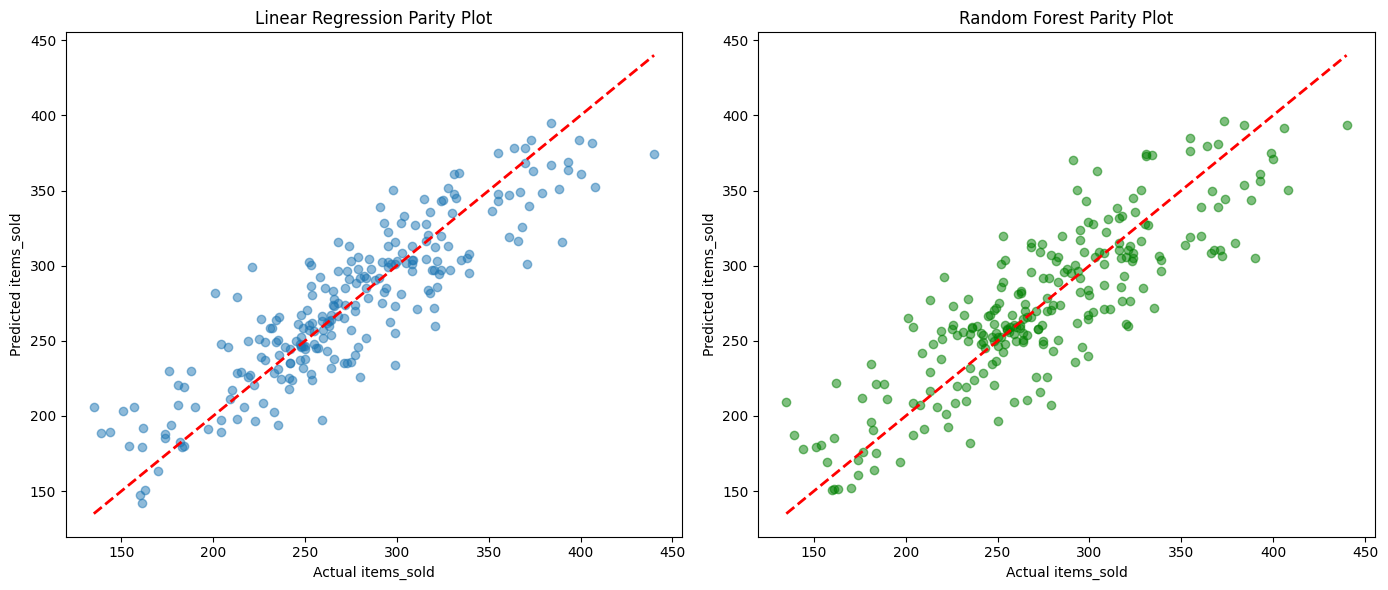


Top 5 Influential Features (Random Forest):
                feature  importance
15          is_festival    0.173605
2      store_size_small    0.165249
5   location_type_urban    0.109710
13          day_of_week    0.090490
16  competition_density    0.065626


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(model, name):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\nModel: {name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")

    return pipeline, y_pred

# Linear Regression
lr_model = LinearRegression()
lr_pipeline, lr_pred = evaluate_model(lr_model, "Linear Regression")

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_pipeline, rf_pred = evaluate_model(rf_model, "Random Forest Regressor")

# Plots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression Parity Plot')
plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest Parity Plot')
plt.xlabel('Actual items_sold')
plt.ylabel('Predicted items_sold')

plt.tight_layout()
plt.savefig('parity_plots.png')
print("\nVisualization Generated : parity_plots.png")
plt.show()

# Feature Importances (Random Forest)
cat_ohe_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names = list(cat_ohe_names) + numerical_features
importances = rf_pipeline.named_steps['regressor'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)
print("\nTop 5 Influential Features (Random Forest):")
print(importance_df.head(5))